import all the libraries

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 


In [3]:
df=pd.read_csv('loan.csv')
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 531.6 KB
None


In [4]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 531.6 KB


In [6]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [7]:
numerical_value = df[
    ['no_of_dependents',
     'income_annum',
     'loan_amount',
     'loan_term']
]

corr = numerical_value.corr()

print(corr)

                  no_of_dependents  income_annum  loan_amount  loan_term
no_of_dependents          1.000000      0.007266    -0.003366  -0.020111
income_annum              0.007266      1.000000     0.927470   0.011488
loan_amount              -0.003366      0.927470     1.000000   0.008437
loan_term                -0.020111      0.011488     0.008437   1.000000


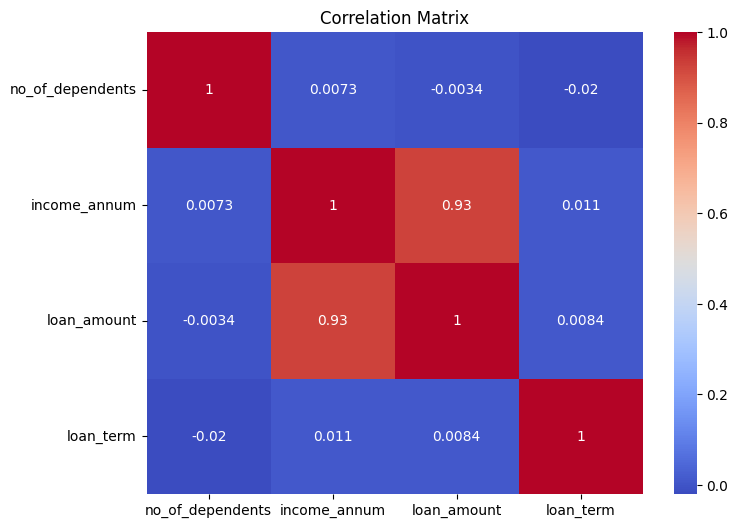

In [8]:


plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [9]:
print(df[['no_of_dependents',
          'income_annum',
          'loan_amount',
          'loan_term']].describe())

       no_of_dependents  income_annum   loan_amount    loan_term
count       4269.000000  4.269000e+03  4.269000e+03  4269.000000
mean           2.498712  5.059124e+06  1.513345e+07    10.900445
std            1.695910  2.806840e+06  9.043363e+06     5.709187
min            0.000000  2.000000e+05  3.000000e+05     2.000000
25%            1.000000  2.700000e+06  7.700000e+06     6.000000
50%            3.000000  5.100000e+06  1.450000e+07    10.000000
75%            4.000000  7.500000e+06  2.150000e+07    16.000000
max            5.000000  9.900000e+06  3.950000e+07    20.000000


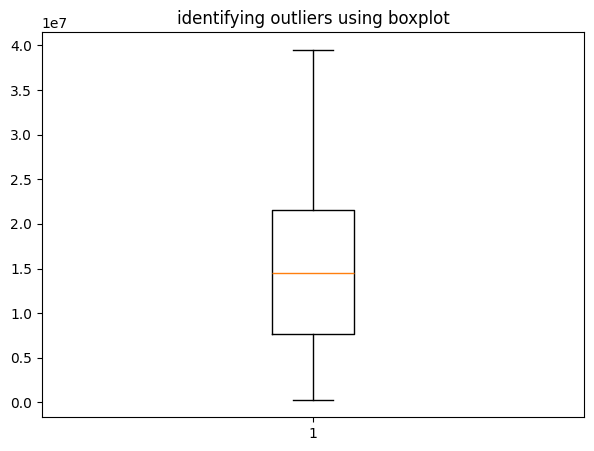

In [10]:
plt.figure(figsize=(7,5))
plt.boxplot(
    x=df['loan_amount']
)
plt.title("identifying outliers using boxplot")
plt.show()

Text(0.5, 1.0, 'bar chat of self_employed employees')

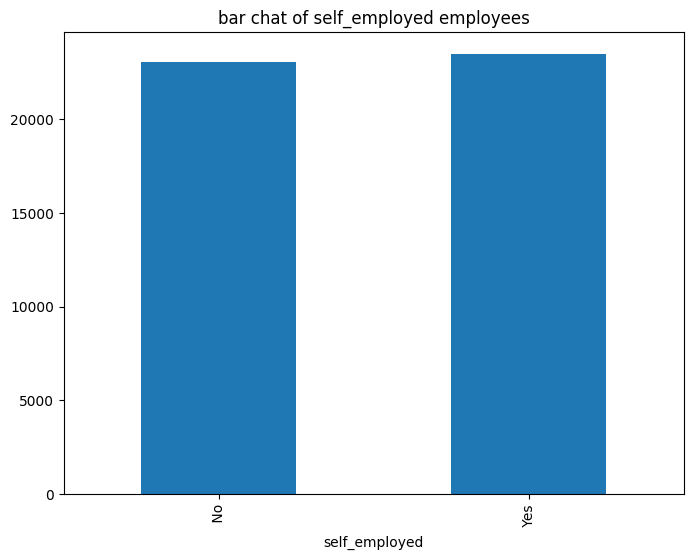

In [11]:
grouped=df.groupby('self_employed')['loan_term'].sum()
grouped.plot(kind="bar",figsize=(8,6))
plt.title("bar chat of self_employed employees")

Text(0.5, 1.0, 'bar chat of self_employed employees')

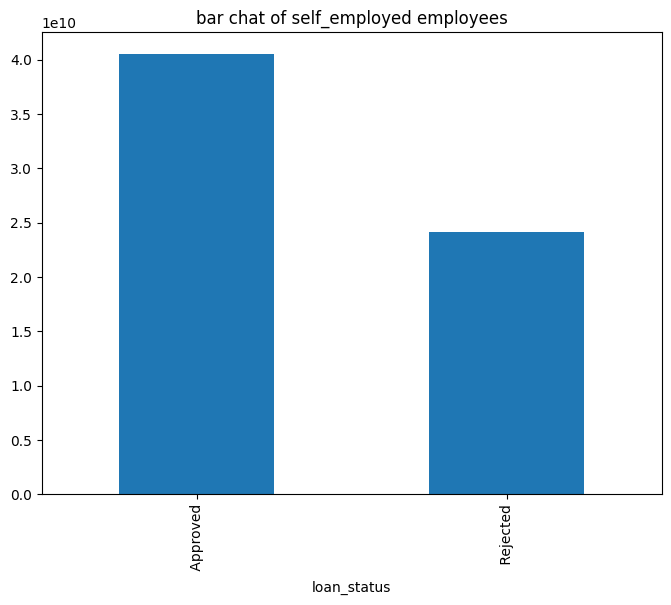

In [12]:
grouped=df.groupby('loan_status')['loan_amount'].sum()
grouped.plot(kind="bar",figsize=(8,6))
plt.title("bar chat of self_employed employees")

In [13]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [14]:
print(df['loan_status'].value_counts())
print(df['loan_status'].value_counts(normalize=True))

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64
loan_status
Approved    0.62216
Rejected    0.37784
Name: proportion, dtype: float64


feature engineering

In [15]:
df['total_assets']=(
    df['residential_assets_value']
    + df['commercial_assets_value']
    + df['luxury_assets_value']
    + df['bank_asset_value']
)

In [16]:
df[['residential_assets_value',
   'commercial_assets_value',
   'luxury_assets_value',
   'bank_asset_value',
   'total_assets']].head()

,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,total_assets
0,2400000,17600000,22700000,8000000,50700000
1,2700000,2200000,8800000,3300000,17000000
2,7100000,4500000,33300000,12800000,57700000
3,18200000,3300000,23300000,7900000,52700000
4,12400000,8200000,29400000,5000000,55000000


In [17]:
df['loan_income_ratio'] = (
    df['loan_amount'] /
    df['income_annum'].replace(0, np.nan)
)

In [18]:
df['loan_asset_ratio'] = (
    df['loan_amount'] /
    df['total_assets'].replace(0, np.nan)
)


In [19]:
print(df.columns.tolist())

['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status', 'total_assets', 'loan_income_ratio', 'loan_asset_ratio']


In [20]:
print(df[['total_assets',
          'loan_income_ratio',
          'loan_asset_ratio']].isnull().sum())

total_assets         0
loan_income_ratio    0
loan_asset_ratio     0
dtype: int64


In [21]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,total_assets,loan_income_ratio,loan_asset_ratio
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved,50700000,3.114583,0.589744
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected,17000000,2.975610,0.717647
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected,57700000,3.263736,0.514731
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected,52700000,3.743902,0.582543
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected,55000000,2.469388,0.440000


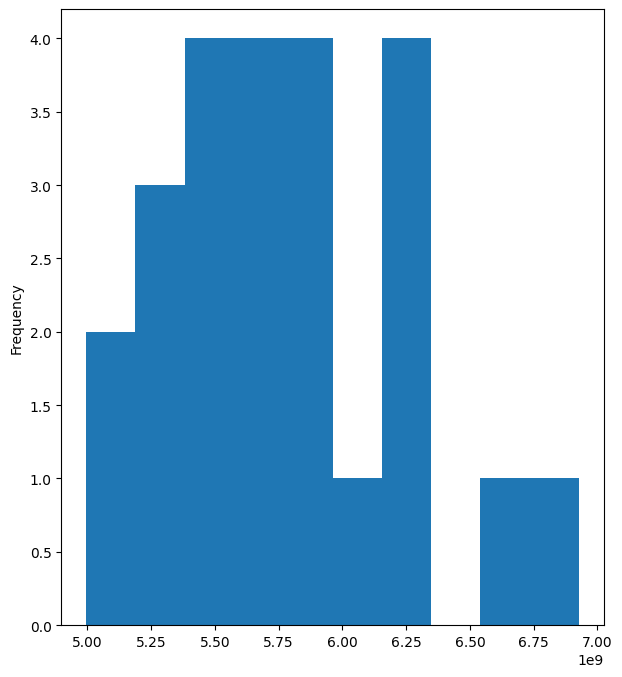

In [22]:
group=df.groupby(['self_employed','education','no_of_dependents'])['total_assets'].sum()
group.plot(kind="hist",figsize=(7,8))
plt.show()

In [23]:
print(df[['total_assets',
          'loan_income_ratio',
          'loan_asset_ratio']].head())

   total_assets  loan_income_ratio  loan_asset_ratio
0      50700000           3.114583          0.589744
1      17000000           2.975610          0.717647
2      57700000           3.263736          0.514731
3      52700000           3.743902          0.582543
4      55000000           2.469388          0.440000


In [24]:
import numpy as np

df.replace([np.inf, -np.inf], np.nan, inplace=True)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,total_assets,loan_income_ratio,loan_asset_ratio
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved,50700000,3.114583,0.589744
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected,17000000,2.975610,0.717647
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected,57700000,3.263736,0.514731
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected,52700000,3.743902,0.582543
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected,55000000,2.469388,0.440000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected,7400000,2.300000,0.310811
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved,20000000,3.424242,0.565000
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected,39000000,3.676923,0.612821
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved,28800000,3.121951,0.444444


In [25]:
print(df.isnull().sum())

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
total_assets                0
loan_income_ratio           0
loan_asset_ratio            0
dtype: int64


In [26]:
df['education'] = df['education'].str.strip()
df['self_employed'] = df['self_employed'].str.strip()


In [27]:
print(df['education'].unique())
print(df['self_employed'].unique())

<ArrowStringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


In [28]:
df['education'] = df['education'].map({
    'Graduate': 1,
    'Not Graduate': 0
})

df['self_employed'] = df['self_employed'].map({
    'Yes': 1,
    'No': 0
})

In [29]:
print(df[['education', 'self_employed']].isnull().sum())

education        0
self_employed    0
dtype: int64


In [30]:
x = df.drop(columns=['loan_status', 'loan_id'])
y = df['loan_status']

In [31]:
from sklearn.model_selection import train_test_split

df['loan_status'] = df['loan_status'].str.strip()

x = df.drop(columns=['loan_status', 'loan_id'])
y = df['loan_status']

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    random_state=42,
    test_size=0.2
)

print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(3415, 14) (854, 14) (3415,) (854,)


In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [33]:
rf_pred=rf_model.predict(x_test)
print(rf_pred)

['Rejected' 'Approved' 'Rejected' 'Approved' 'Approved' 'Approved'
 'Approved' 'Rejected' 'Approved' 'Rejected' 'Rejected' 'Approved'
 'Approved' 'Rejected' 'Rejected' 'Approved' 'Approved' 'Approved'
 'Approved' 'Rejected' 'Approved' 'Rejected' 'Rejected' 'Rejected'
 'Approved' 'Approved' 'Approved' 'Approved' 'Approved' 'Rejected'
 'Approved' 'Rejected' 'Rejected' 'Approved' 'Rejected' 'Rejected'
 'Approved' 'Approved' 'Approved' 'Rejected' 'Rejected' 'Approved'
 'Approved' 'Approved' 'Approved' 'Approved' 'Approved' 'Approved'
 'Approved' 'Rejected' 'Approved' 'Approved' 'Rejected' 'Approved'
 'Approved' 'Approved' 'Approved' 'Approved' 'Approved' 'Approved'
 'Approved' 'Approved' 'Rejected' 'Rejected' 'Rejected' 'Approved'
 'Approved' 'Approved' 'Approved' 'Approved' 'Approved' 'Approved'
 'Approved' 'Approved' 'Rejected' 'Approved' 'Rejected' 'Approved'
 'Approved' 'Approved' 'Rejected' 'Rejected' 'Rejected' 'Approved'
 'Rejected' 'Rejected' 'Approved' 'Approved' 'Rejected' 'Rejec

In [34]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print("accuracy",accuracy_score(y_test,rf_pred))


accuracy 1.0


In [35]:
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))



[[536   0]
 [  0 318]]
              precision    recall  f1-score   support

    Approved       1.00      1.00      1.00       536
    Rejected       1.00      1.00      1.00       318

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854



In [36]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=x_train.columns
).sort_values(ascending=False)

print(importance)

cibil_score                 0.790288
loan_term                   0.066637
loan_income_ratio           0.035328
loan_asset_ratio            0.025720
loan_amount                 0.012384
luxury_assets_value         0.011285
total_assets                0.011079
residential_assets_value    0.010317
commercial_assets_value     0.010111
income_annum                0.009566
bank_asset_value            0.009136
no_of_dependents            0.005126
education                   0.001552
self_employed               0.001472
dtype: float64


In [37]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model,
    x,
    y,
    cv=5,
    scoring='accuracy'
)

print("CV Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

CV Scores: [0.99882904 0.99765808 0.99882904 1.         1.        ]
Mean CV Accuracy: 0.999063231850117


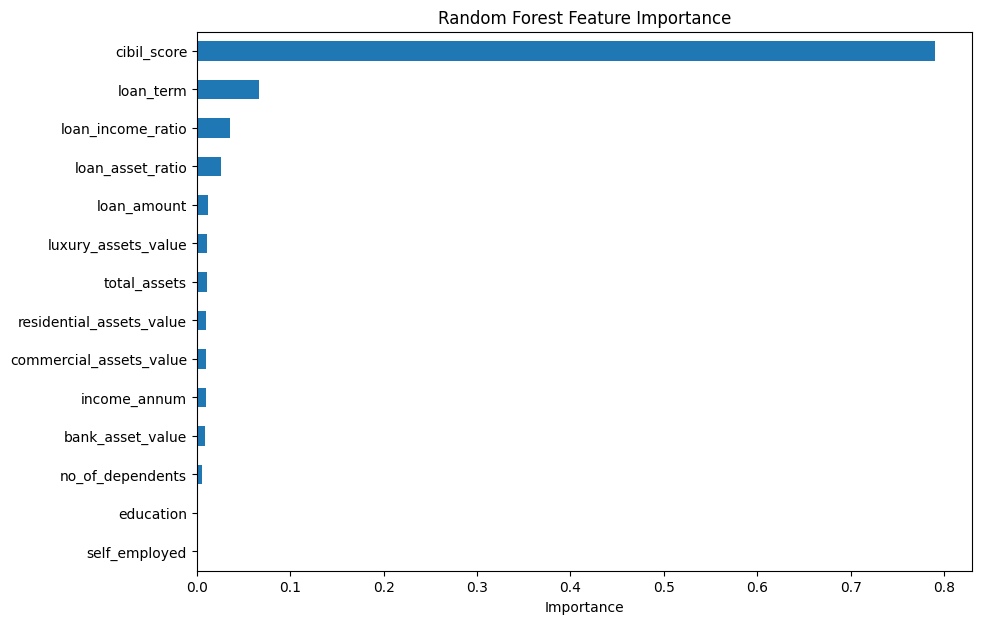

In [38]:
importance.sort_values().plot(
    kind='barh',
    figsize=(10, 7),
    title='Random Forest Feature Importance'
)

plt.xlabel('Importance')
plt.show()

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   loan_id                   4269 non-null   int64  
 1   no_of_dependents          4269 non-null   int64  
 2   education                 4269 non-null   int64  
 3   self_employed             4269 non-null   int64  
 4   income_annum              4269 non-null   int64  
 5   loan_amount               4269 non-null   int64  
 6   loan_term                 4269 non-null   int64  
 7   cibil_score               4269 non-null   int64  
 8   residential_assets_value  4269 non-null   int64  
 9   commercial_assets_value   4269 non-null   int64  
 10  luxury_assets_value       4269 non-null   int64  
 11  bank_asset_value          4269 non-null   int64  
 12  loan_status               4269 non-null   str    
 13  total_assets              4269 non-null   int64  
 14  loan_income_ratio  

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [ ]:
x_train,y_train,x_test,y_test=train_test_split(
    x,
    y,
    random_state=42,
    test_size=0.2
)

In [46]:
from sklearn.model_selection import train_test_split

# Features
X = df.drop(columns=['loan_status', 'loan_id'])

# Target — ONLY loan_status
y = df['loan_status']

# Split
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", x_train.shape)
print("X_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3415, 14)
X_test: (854, 14)
y_train: (3415,)
y_test: (854,)


In [47]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [48]:
y_pred=model.predict(x_train)
print(y_pred)

['Rejected' 'Approved' 'Approved' ... 'Rejected' 'Approved' 'Rejected']


In [51]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print("accuracy:",accuracy_score(y_test,y_pred))

ValueError: Found input variables with inconsistent numbers of samples: [854, 3415]

In [52]:
# Test data par prediction
y_pred = model.predict(x_test)

print("y_test:", y_test.shape)
print("y_pred:", y_pred.shape)

y_test: (854,)
y_pred: (854,)


In [53]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.810304449648712

Classification Report:
              precision    recall  f1-score   support

    Approved       0.80      0.92      0.86       531
    Rejected       0.83      0.63      0.72       323

    accuracy                           0.81       854
   macro avg       0.81      0.78      0.79       854
weighted avg       0.81      0.81      0.80       854


Confusion Matrix:
[[488  43]
 [119 204]]
